# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.

## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).



# Практическая часть

В данной работе вам предлагается реализовать и исследовать простую спайковую нейронную сеть на основе модели LIF с обучением по правилу STDP. Вы должны:

1.  Реализовать модель LIF-нейрона и исследовать его отклик на различные входные токи.
2.  Создать сеть из нескольких LIF-нейронов (например, входной слой, скрытый слой) и визуализировать распространение спайковой активности.
3.  Реализовать правило обучения STDP для синаптических связей.
4.  Обучить сеть на простой задаче (например, ассоциации паттернов) или классификации простых спайковых последовательностей.
5.  Проанализировать динамику весов, итоговую активность сети и эффективность обучения.

## Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.random.seed(42)

## Реализация LIF нейрона

In [2]:
# Определение параметров нейрона LIF
@dataclass
class LIFNeuron:
    tau_m: float = 20.0    # Постоянная времени мембраны (мс)
    v_rest: float = -70.0  # Потенциал покоя (мВ)
    v_thresh: float = -55.0 # Пороговый потенциал (мВ)
    v_reset: float = -75.0 # Потенциал сброса (мВ)
    r_m: float = 10.0      # Мембранное сопротивление (МОм)
    tau_ref: float = 4.0   # Рефрактерный период (мс)

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        """Один шаг интегрирования. Возвращает True, если был спайк."""
        # Проверка рефрактерности
        if t < self.refractory_until:
            self.v = self.v_reset
            return False

        # Интегрирование уравнения LIF (простая Эйлерова схема)
        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        # Проверка на срабатывание
        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True
        return False

## Функция симуляции

In [3]:
def simulate_neuron(tau_m, I_inj=3.0):

    dt = 0.1
    T = 200
    t_range = np.arange(0, T, dt)

    neuron = LIFNeuron(tau_m=tau_m)

    v_trace = []
    spike_times = []

    for t in t_range:

        spike = neuron.step(I_inj, dt, t)

        v_trace.append(neuron.v)

        if spike:
            spike_times.append(t)

    return t_range, v_trace, spike_times

## Проверка работы модели

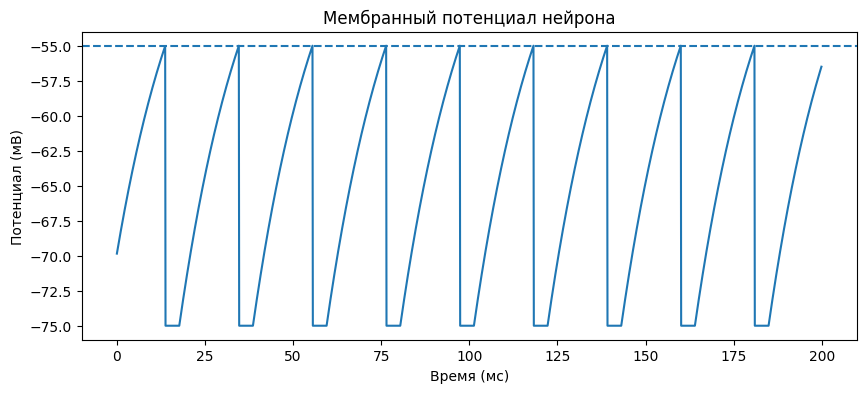

Количество спайков: 9


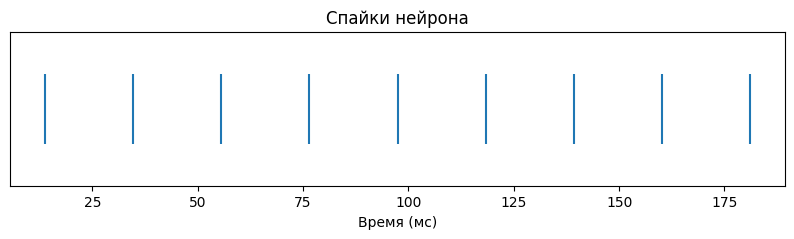

In [4]:
t, v, spikes = simulate_neuron(tau_m=20)

plt.figure(figsize=(10,4))
plt.plot(t, v)
plt.axhline(-55, linestyle="--")
plt.title("Мембранный потенциал нейрона")
plt.xlabel("Время (мс)")
plt.ylabel("Потенциал (мВ)")
plt.show()

print("Количество спайков:", len(spikes))

plt.figure(figsize=(10,2))

plt.eventplot(spikes)

plt.title("Спайки нейрона")
plt.xlabel("Время (мс)")
plt.yticks([])
plt.show()

## Исследование влияния постоянной времени мембраны (tau_m) на параметры

tau_m = 5  spikes = 25  first spike = 3.4000000000000004
tau_m = 10  spikes = 16  first spike = 6.800000000000001
tau_m = 20  spikes = 9  first spike = 13.8
tau_m = 40  spikes = 5  first spike = 27.6
tau_m = 80  spikes = 3  first spike = 55.400000000000006
tau_m = 120  spikes = 2  first spike = 83.10000000000001
tau_m = 160  spikes = 1  first spike = 110.80000000000001


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

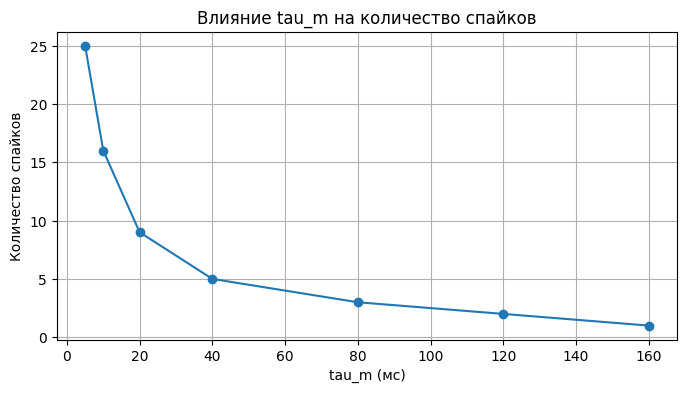

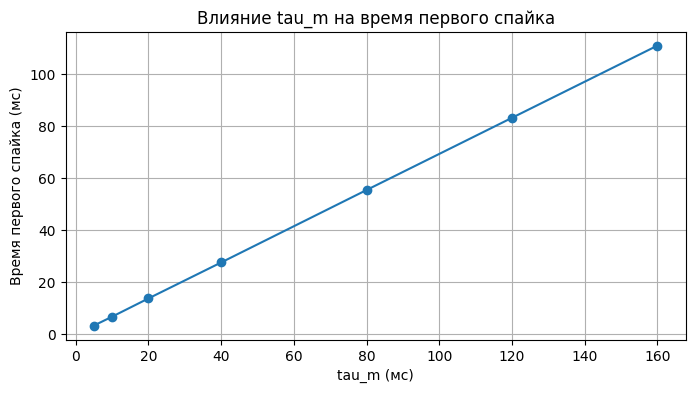

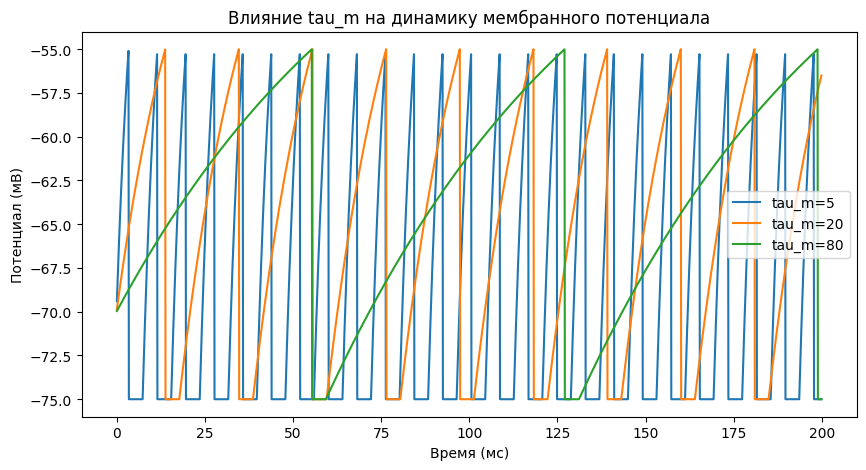

In [6]:
tau_values = [5, 10, 20, 40, 80, 120, 160]

spike_counts = []
first_spike_times = []

# Запуск экспериментов
for tau in tau_values:
    
    t, v, spikes = simulate_neuron(tau)
    
    spike_counts.append(len(spikes))
    
    if len(spikes) > 0:
        first_spike_times.append(spikes[0])
    else:
        first_spike_times.append(None)
        
    print("tau_m =", tau,
          " spikes =", len(spikes),
          " first spike =", spikes[0] if spikes else None)
    
    plt.figure(figsize=(8,4))

# График влияния tau_m на количество спайков
plt.plot(tau_values, spike_counts, marker='o')

plt.title("Влияние tau_m на количество спайков")
plt.xlabel("tau_m (мс)")
plt.ylabel("Количество спайков")

plt.grid()
plt.show()

# График скорости реакции
plt.figure(figsize=(8,4))

plt.plot(tau_values, first_spike_times, marker='o')

plt.title("Влияние tau_m на время первого спайка")
plt.xlabel("tau_m (мс)")
plt.ylabel("Время первого спайка (мс)")

plt.grid()
plt.show()

# Сравнение мембранного потенциала
plt.figure(figsize=(10,5))

for tau in [5, 20, 80]:
    
    t, v, spikes = simulate_neuron(tau)
    plt.plot(t, v, label=f"tau_m={tau}")

plt.legend()
plt.xlabel("Время (мс)")
plt.ylabel("Потенциал (мВ)")
plt.title("Влияние tau_m на динамику мембранного потенциала")

plt.show()

### Выводы

1. При увеличении tau_m количество спайков уменьшается. Нейрон начинает накапливать потенциал медленнее, поэтому порог достигается реже.
2. С увеличением tau_m возрастает время появления первого спайка. Это означает, что нейрон реагирует на входной сигнал медленнее.
3. Увеличение tau_m приводит к замедлению накопления мембранного потенциала и снижению частоты генерации спайков.

## Исследование влияния постоянной времени мембраны (tau_m) на точность классификации и скорость реакции сети.

tau_m = 5 | accuracy = 0.500 | reaction time = 4.31
tau_m = 10 | accuracy = 0.500 | reaction time = 8.71
tau_m = 15 | accuracy = 0.500 | reaction time = 13.10
tau_m = 20 | accuracy = 0.500 | reaction time = 17.51
tau_m = 25 | accuracy = 0.500 | reaction time = 21.91
tau_m = 30 | accuracy = 0.500 | reaction time = 26.31
tau_m = 35 | accuracy = 0.500 | reaction time = 30.72
tau_m = 40 | accuracy = 0.500 | reaction time = 35.12
tau_m = 45 | accuracy = 0.500 | reaction time = 39.52
tau_m = 50 | accuracy = 0.500 | reaction time = 43.92
tau_m = 55 | accuracy = 0.500 | reaction time = 48.33
tau_m = 60 | accuracy = 0.500 | reaction time = 52.72
tau_m = 65 | accuracy = 0.500 | reaction time = 57.13
tau_m = 70 | accuracy = 0.500 | reaction time = 61.52
tau_m = 75 | accuracy = 0.533 | reaction time = 60.80
tau_m = 80 | accuracy = 0.533 | reaction time = 64.86
tau_m = 85 | accuracy = 0.567 | reaction time = 63.41
tau_m = 90 | accuracy = 0.600 | reaction time = 61.67
tau_m = 95 | accuracy = 0.633 |

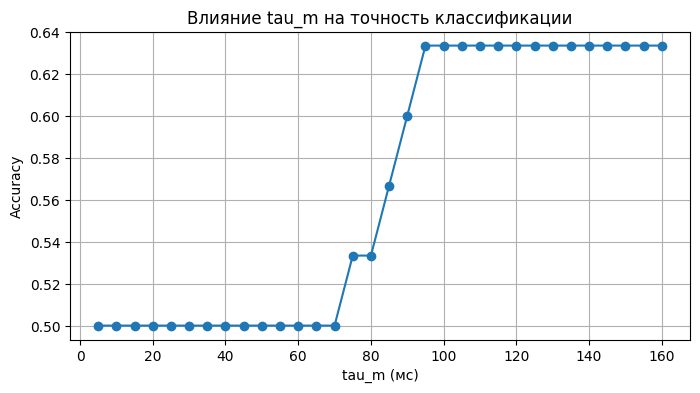

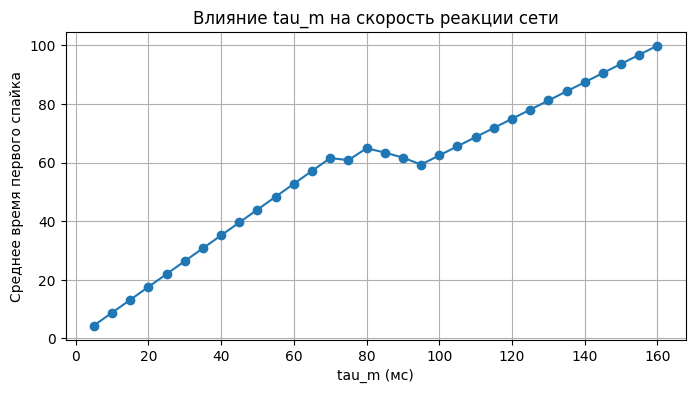

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Загружаем датасет
iris = load_iris()

X = iris.data
y = iris.target

# Берем только 2 класса для бинарной классификации
mask = y < 2
X = X[mask]
y = y[mask]

# Нормализация
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Классификация одного объекта
def classify_sample(tau_m, features, dt=0.1, T=200):

    neuron = LIFNeuron(tau_m=tau_m)

    # преобразуем признаки в входной ток
    I_inj = np.sum(features) * 2

    t_range = np.arange(0, T, dt)

    first_spike = None

    for t in t_range:

        spike = neuron.step(I_inj, dt, t)

        if spike and first_spike is None:
            first_spike = t

    prediction = 1 if first_spike is not None else 0

    return prediction, first_spike


# Оценка модели
def evaluate_tau(tau_m):

    correct = 0
    reaction_times = []

    for features, label in zip(X_test, y_test):

        pred, first_spike = classify_sample(tau_m, features)

        if pred == label:
            correct += 1

        if first_spike is not None:
            reaction_times.append(first_spike)

    accuracy = correct / len(y_test)
    reaction_time = np.mean(reaction_times) if reaction_times else None

    return accuracy, reaction_time


# Исследуем разные tau_m
tau_values = list(range(5, 161, 5))

accuracies = []
reaction_times = []

for tau in tau_values:

    acc, react = evaluate_tau(tau)

    accuracies.append(acc)
    reaction_times.append(react)

    print(f"tau_m = {tau} | accuracy = {acc:.3f} | reaction time = {react:.2f}")


# График точности
plt.figure(figsize=(8,4))

plt.plot(tau_values, accuracies, marker='o')

plt.title("Влияние tau_m на точность классификации")
plt.xlabel("tau_m (мс)")
plt.ylabel("Accuracy")

plt.grid()
plt.show()

# График скорости реакции
plt.figure(figsize=(8,4))

plt.plot(tau_values, reaction_times, marker='o')

plt.title("Влияние tau_m на скорость реакции сети")
plt.xlabel("tau_m (мс)")
plt.ylabel("Среднее время первого спайка")

plt.grid()
plt.show()


### Выводы
1. Точность классификации
- При малых значениях tau_m (примерно от 5 до 70) точность классификации остаётся на уровне около 0.5, что соответствует почти случайному угадыванию классов.
- При увеличении tau_m примерно после 75–90 мс точность начинает постепенно расти.
- Максимальная точность достигается при tau_m около 95–100 мс и выше, где она стабилизируется примерно на уровне 0.63–0.64.
- Увеличение tau_m улучшает способность нейрона различать входные сигналы

2. Но с увеличением tau_m растет и время появление появления первого спайка (т.е. скорость уменьшается)

Для данного датасета лучшим вариантом будет tau_m = 95